<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Ensembles Comparison: RF vs. XGBoost vs. LightGBM
</p>

In [1]:
# Imports - core utils, data wrangling, and plotting

import os

import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load Per-Model Bayesian CV Results
</p>

In [2]:
# Paths - aligned with the RF, XGBoost, and LightGBM notebooks
CV_RESULTS_DIR = "CV_Results"
FIGURES_DIR    = "Figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

CV_RESULTS_PATHS = {
    "RF":       os.path.join(CV_RESULTS_DIR, "rf_bayes_cv_results.csv"),
    "XGBoost":  os.path.join(CV_RESULTS_DIR, "xgb_bayes_cv_results.csv"),
    "LightGBM": os.path.join(CV_RESULTS_DIR, "lgb_bayes_cv_results.csv"),
}

MAX_DEPTH_CAP = 10  # full max_depth search range for RF/XGBoost/LightGBM (Integer(1, 10));
                     # which of these depths actually get plotted is chosen in the plotting cell


def best_per_depth(cv_results_path, max_depth_cap=MAX_DEPTH_CAP):
    """Best (max score / min RMSE) CV RMSE and its SD per max_depth, from a saved
    BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        "param_max_depth",
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df["param_max_depth"] = pd.to_numeric(df["param_max_depth"], errors="coerce")
    df = df[df["param_max_depth"] <= max_depth_cap]

    rows = []
    for depth in sorted(df["param_max_depth"].dropna().unique()):
        df_depth = df[df["param_max_depth"] == depth]
        idx = df_depth["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_depth.loc[idx]
        rows.append({
            "max_depth": int(depth),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)


# Best-per-depth CV RMSE summary for each ensemble model
per_model_cv = {name: best_per_depth(path) for name, path in CV_RESULTS_PATHS.items()}

combined_cv_df = pd.concat(
    [df.assign(model=name) for name, df in per_model_cv.items()],
    ignore_index=True,
)[["model", "max_depth", "CV_RMSE", "STD_RMSE"]]

if combined_cv_df.empty:
    raise ValueError("No CV rows found for any ensemble model.")

display(combined_cv_df.pivot(index="max_depth", columns="model", values="CV_RMSE").round(4))


model,LightGBM,RF,XGBoost
max_depth,,,
1,6.6701,12.2540,6.6679
2,5.8388,8.1638,5.8395
3,5.8732,5.9637,5.8415
4,5.9589,5.9058,5.8949
5,5.9429,5.9082,5.8478
6,5.9940,5.9103,6.0077
7,6.2069,5.9087,6.1634
8,6.0721,5.9297,6.1076
9,6.1114,5.9520,6.1253


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Combined CV RMSE by max_depth
</p>

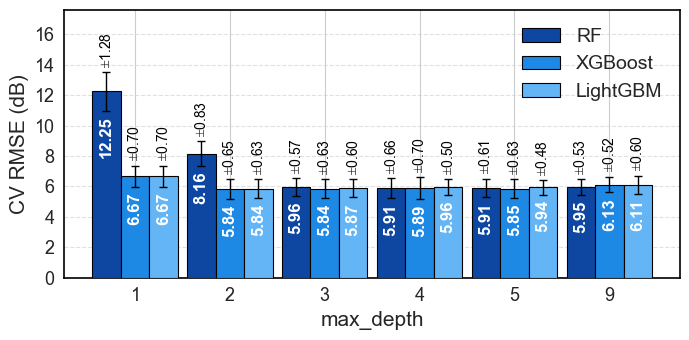

Saved figure: Figures/RF_bestRMSE_STD_perDepth.png


In [10]:
# Plot and save the combined RF / XGBoost / LightGBM CV RMSE figure by max_depth

tick_fontsize   = 13
axis_labelsize  = 15
legend_fontsize = 14
value_fontsize  = 12
std_fontsize    = 10
y_tick_step     = 2  # dB spacing between y-axis ticks - lower it for more ticks, raise for fewer

# Edit this list to choose exactly which max_depth values appear on the x-axis
# (need not be contiguous - e.g. [1, 2, 3, 4, 6, 7] skips 5 and 8+).
SELECTED_DEPTHS = [1, 2, 3, 4, 5, 9]

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

# Blue-gradient theme: model identity is encoded by lightness (light -> dark),
# so the grouping stays legible in a grayscale/print reproduction of the paper.
model_order  = ["RF", "XGBoost", "LightGBM"]
model_colors = {
    "RF":       "#0d47a1",  # dark blue
    "XGBoost":  "#1e88e5",  # mid blue
    "LightGBM": "#64b5f6",  # light blue
}

available_depths = set(combined_cv_df["max_depth"].unique())
depths = sorted(d for d in SELECTED_DEPTHS if d in available_depths)

missing_depths = sorted(set(SELECTED_DEPTHS) - available_depths)
if missing_depths:
    print(f"Note: no CV results for max_depth {missing_depths}; skipping.")
if not depths:
    raise ValueError("None of SELECTED_DEPTHS were found in combined_cv_df.")

plot_df = combined_cv_df[combined_cv_df["max_depth"].isin(depths)]

x = np.arange(len(depths))
n_models = len(model_order)
bar_width = 0.3

fig, ax = plt.subplots(figsize=(7, 3.5))

for i, model in enumerate(model_order):
    sub = (
        plot_df[plot_df["model"] == model]
        .set_index("max_depth")
        .reindex(depths)
    )
    offset = (i - (n_models - 1) / 2) * bar_width
    bar_x = x + offset

    ax.bar(
        bar_x,
        sub["CV_RMSE"],
        bar_width,
        yerr=sub["STD_RMSE"],
        capsize=3,
        color=model_colors[model],
        edgecolor="black",
        linewidth=0.8,
        zorder=3,
        error_kw=dict(elinewidth=1, capthick=1),
        label=model,
    )

    for xi, cv, sd in zip(bar_x, sub["CV_RMSE"], sub["STD_RMSE"]):
        if pd.isna(cv):
            continue

        # Mean CV RMSE, set inside the bar near its lower error whisker
        ax.annotate(
            f"{cv:.2f}",
            (xi, cv - sd),
            textcoords="offset points",
            xytext=(0, -4),
            ha="center",
            va="top",
            fontsize=value_fontsize,
            color="white",
            fontweight="bold",
            rotation=90,
            zorder=4,
        )

        # SD, set above the upper error whisker
        ax.annotate(
            rf"$\pm${sd:.2f}",
            (xi, cv + sd),
            textcoords="offset points",
            xytext=(0, 3),
            ha="center",
            va="bottom",
            fontsize=std_fontsize,
            color="black",
            rotation=90,
            zorder=4,
        )

ax.set_xlabel("max_depth", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
ax.set_xticks(x)
ax.set_xticklabels([f"{int(d)}" for d in depths], fontsize=tick_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

y_top = float((plot_df["CV_RMSE"] + plot_df["STD_RMSE"]).max())
ax.set_ylim(0, y_top * 1.3)
ax.yaxis.set_major_locator(MultipleLocator(y_tick_step))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax.legend(loc="upper right", fontsize=legend_fontsize, frameon=False)

fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "RF_bestRMSE_STD_perDepth.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Load kNN and SVR CV Results
</p>

In [4]:
# Paths for kNN and SVR CV results (independent of the tree-ensemble cells above)
KNN_CV_RESULTS_PATH = os.path.join(CV_RESULTS_DIR, "knn_bayes_cv_results.csv")
SVR_C_SWEEP_PATH    = os.path.join(CV_RESULTS_DIR, "svr_c_sweep_cv.csv")


def best_per_param(cv_results_path, param_col, out_name, param_cast=float):
    """Best (max score / min RMSE) CV RMSE and its SD per distinct value of
    `param_col`, from a saved BayesSearchCV cv_results_ table."""
    if not os.path.exists(cv_results_path):
        raise FileNotFoundError(f"Missing CV results file: {cv_results_path}")

    df = pd.read_csv(cv_results_path)
    required_cols = {
        param_col,
        "mean_test_neg_root_mean_squared_error",
        "std_test_neg_root_mean_squared_error",
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{cv_results_path} is missing columns: {sorted(missing)}")

    df[param_col] = pd.to_numeric(df[param_col], errors="coerce")

    rows = []
    for value in sorted(df[param_col].dropna().unique()):
        df_value = df[df[param_col] == value]
        idx = df_value["mean_test_neg_root_mean_squared_error"].idxmax()
        row = df_value.loc[idx]
        rows.append({
            out_name: param_cast(value),
            "CV_RMSE": -float(row["mean_test_neg_root_mean_squared_error"]),
            "STD_RMSE": float(row["std_test_neg_root_mean_squared_error"]),
        })

    return pd.DataFrame(rows)


def load_svr_c_sweep(c_sweep_path):
    """Best CV RMSE and its SD per C, from the SVR C-sensitivity sweep table
    (already one row per C, unlike the raw BayesSearchCV cv_results_ tables)."""
    if not os.path.exists(c_sweep_path):
        raise FileNotFoundError(f"Missing C-sweep file: {c_sweep_path}")

    df = pd.read_csv(c_sweep_path)
    required_cols = {"C", "rmse_mean", "rmse_std"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"{c_sweep_path} is missing columns: {sorted(missing)}")

    out = pd.DataFrame({
        "log10_C": np.log10(df["C"].astype(float)),
        "CV_RMSE": df["rmse_mean"].astype(float),
        "STD_RMSE": df["rmse_std"].astype(float),
    })
    return out.sort_values("log10_C").reset_index(drop=True)


# Best-per-K summary for kNN, best-per-C summary for SVR
cv_knn_df = best_per_param(KNN_CV_RESULTS_PATH, "param_knn__n_neighbors", "K", param_cast=int)
cv_svr_df = load_svr_c_sweep(SVR_C_SWEEP_PATH)

display(cv_knn_df.round(4))
display(cv_svr_df.round(4))


,K,CV_RMSE,STD_RMSE
0,20,6.6464,0.5592
1,26,6.6332,0.6411
2,30,7.6602,1.1454
3,49,8.5539,1.7127
4,59,6.9802,0.6897
5,61,7.4828,0.9167
6,64,6.9697,0.6839
7,68,8.5230,1.7325
8,69,7.4605,0.9129
9,84,6.4994,0.4971


,log10_C,CV_RMSE,STD_RMSE
0,-3.0,20.1984,1.5121
1,-2.0,19.1383,1.6121
2,-1.0,12.2740,2.4692
3,0.0,10.3964,2.9743
4,1.0,9.4962,2.7625
5,2.0,8.8713,2.3174
6,3.0,9.8409,2.4247


<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
kNN vs. SVR: CV RMSE (2-column comparison)
</p>

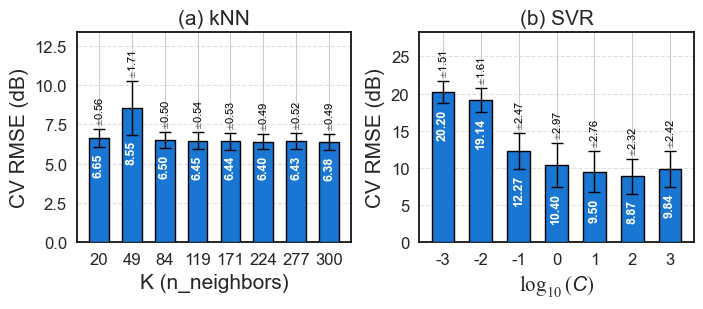

Saved figure: Figures/KNN_SVR_bestRMSE_STD_comparison.png


In [8]:
# Plot and save kNN (vs K) and SVR (vs log10 C) CV RMSE side by side, 2 columns

tick_fontsize   = 12
axis_labelsize  = 15
value_fontsize  = 9
std_fontsize    = 8

# Edit these to choose exactly which K / log10(C) values appear on each panel.
SELECTED_K       = [20, 49, 84, 119, 171, 224, 277, 300]
SELECTED_LOG10_C = sorted(cv_svr_df["log10_C"].round().astype(int).unique())

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
sns.set_style("whitegrid")

bar_color = "#1976d2"  # same blue used across the individual model notebooks


def annotate_bar(ax, xi, cv, sd):
    # Mean CV RMSE, set inside the bar near its lower error whisker
    ax.annotate(
        f"{cv:.2f}",
        (xi, cv - sd),
        textcoords="offset points",
        xytext=(0, -4),
        ha="center",
        va="top",
        fontsize=value_fontsize,
        color="white",
        fontweight="bold",
        rotation=90,
        zorder=4,
    )
    # SD, set above the upper error whisker
    ax.annotate(
        rf"$\pm${sd:.2f}",
        (xi, cv + sd),
        textcoords="offset points",
        xytext=(0, 3),
        ha="center",
        va="bottom",
        fontsize=std_fontsize,
        color="black",
        rotation=90,
        zorder=4,
    )


def style_panel(ax, xlabel, title):
    ax.set_xlabel(xlabel, fontsize=axis_labelsize)
    ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
    ax.set_title(title, fontsize=axis_labelsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)


fig, (ax_knn, ax_svr) = plt.subplots(1, 2, figsize=(7, 3.2))

# --- kNN panel ---
knn_plot_df = cv_knn_df[cv_knn_df["K"].isin(SELECTED_K)].sort_values("K").reset_index(drop=True)
if knn_plot_df.empty:
    raise ValueError("None of SELECTED_K were found in cv_knn_df.")

x_knn = np.arange(len(knn_plot_df))
ax_knn.bar(
    x_knn,
    knn_plot_df["CV_RMSE"],
    width=0.6,
    yerr=knn_plot_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_knn, knn_plot_df["CV_RMSE"], knn_plot_df["STD_RMSE"]):
    annotate_bar(ax_knn, xi, cv, sd)

ax_knn.set_xticks(x_knn)
ax_knn.set_xticklabels([f"{int(k)}" for k in knn_plot_df["K"]], fontsize=tick_fontsize)
y_top_knn = float((knn_plot_df["CV_RMSE"] + knn_plot_df["STD_RMSE"]).max())
ax_knn.set_ylim(0, y_top_knn * 1.3)
style_panel(ax_knn, "K (n_neighbors)", "(a) kNN")

# --- SVR panel ---
svr_plot_df = (
    cv_svr_df[cv_svr_df["log10_C"].round().astype(int).isin(SELECTED_LOG10_C)]
    .sort_values("log10_C")
    .reset_index(drop=True)
)
if svr_plot_df.empty:
    raise ValueError("None of SELECTED_LOG10_C were found in cv_svr_df.")

x_svr = np.arange(len(svr_plot_df))
ax_svr.bar(
    x_svr,
    svr_plot_df["CV_RMSE"],
    width=0.6,
    yerr=svr_plot_df["STD_RMSE"],
    capsize=4,
    color=bar_color,
    edgecolor="black",
    linewidth=1,
    zorder=3,
    error_kw=dict(elinewidth=1, capthick=1),
)
for xi, cv, sd in zip(x_svr, svr_plot_df["CV_RMSE"], svr_plot_df["STD_RMSE"]):
    annotate_bar(ax_svr, xi, cv, sd)

ax_svr.set_xticks(x_svr)
ax_svr.set_xticklabels([f"{v:.0f}" for v in svr_plot_df["log10_C"]], fontsize=tick_fontsize)
y_top_svr = float((svr_plot_df["CV_RMSE"] + svr_plot_df["STD_RMSE"]).max())
ax_svr.set_ylim(0, y_top_svr * 1.3)
style_panel(ax_svr, r"$\log_{10}(C)$", "(b) SVR")

fig.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "KNN_SVR_bestRMSE_STD_comparison.png")
#plt.savefig(fig_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

plt.show()
print(f"Saved figure: {fig_path}")